In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import torch
from torchvision import models, transforms


class Fusion:
    def __init__(self, sharp_path: str, colorful_path: str):
        self.img_sharp_bgr = cv2.imread(sharp_path)
        self.img_color_bgr = cv2.imread(colorful_path)
        if self.img_sharp_bgr is None or self.img_color_bgr is None:
            raise ValueError("Could not read one or both images")
        if self.img_sharp_bgr.shape != self.img_color_bgr.shape:
            h = min(self.img_sharp_bgr.shape[0], self.img_color_bgr.shape[0])
            w = min(self.img_sharp_bgr.shape[1], self.img_color_bgr.shape[1])
            self.img_sharp_bgr = cv2.resize(self.img_sharp_bgr, (w, h))
            self.img_color_bgr = cv2.resize(self.img_color_bgr, (w, h))

        self.img_sharp_rgb = cv2.cvtColor(self.img_sharp_bgr, cv2.COLOR_BGR2RGB)
        self.img_color_rgb = cv2.cvtColor(self.img_color_bgr, cv2.COLOR_BGR2RGB)

        self.fcn_model = None

    def freq_stages(self, radius: int = 15):
        sharp = self.img_sharp_rgb.astype(np.float32)
        colorful = self.img_color_rgb.astype(np.float32)
        sharp_low = cv2.GaussianBlur(sharp, (0, 0), sigmaX=radius)
        colorful_low = cv2.GaussianBlur(colorful, (0, 0), sigmaX=radius)
        sharp_high = sharp - sharp_low
        fused = colorful_low + sharp_high
        fused = np.clip(fused, 0, 255).astype(np.uint8)
        return fused

    def run_freq(self):
        fused = self.freq_stages()
        return fused

    def wavelet_stages(self):
        sharp = self.img_sharp_rgb.astype(np.float32)
        colorful = self.img_color_rgb.astype(np.float32)
        fused = np.zeros_like(sharp)
        scales = [2, 5, 10, 20]

        for c in range(3):
            base = gaussian_filter(colorful[:, :, c], sigma=scales[-1])
            prev = sharp[:, :, c]
            channel_details = []
            for sigma in scales:
                blurred = gaussian_filter(sharp[:, :, c], sigma=sigma)
                d = prev - blurred
                channel_details.append(d)
                prev = blurred
            recon = base
            for d in reversed(channel_details):
                recon += d * 1.1
            fused[:, :, c] = recon

        fused = np.clip(fused, 0, 255).astype(np.uint8)
        fused_hsv = cv2.cvtColor(fused, cv2.COLOR_RGB2HSV).astype(np.float32)
        fused_hsv[:, :, 1] = np.clip(fused_hsv[:, :, 1] * 1.1, 0, 255)
        fused_sat = cv2.cvtColor(fused_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        return fused_sat

    def run_wavelet(self):
        fused = self.wavelet_stages()
        return fused

    def luminance_stages(self):
        sharp_lab = cv2.cvtColor(self.img_sharp_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        colorful_lab = cv2.cvtColor(self.img_color_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        sharp_L = sharp_lab[:, :, 0]
        result_lab = colorful_lab.copy()
        result_lab[:, :, 0] = sharp_L
        result = cv2.cvtColor(result_lab.astype(np.uint8), cv2.COLOR_LAB2RGB)
        return result

    def run_luminance(self):
        fused = self.luminance_stages()
        return fused

    def _load_fcn(self):
        if self.fcn_model is None:
            try:
                self.fcn_model = models.segmentation.deeplabv3_resnet101(
                    weights=models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
                )
            except AttributeError:
                self.fcn_model = models.segmentation.deeplabv3_resnet101(pretrained=True)
            self.fcn_model.eval()
        return self.fcn_model

    def fcn_poisson_guided_stages(self):
        model = self._load_fcn()
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((520, 520)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        inp = transform(self.img_sharp_rgb).unsqueeze(0)
        with torch.no_grad():
            out = model(inp)
        out_np = out["out"][0].detach().cpu().numpy()
        seg_small = np.argmax(out_np, axis=0).astype(np.uint8)
        seg = cv2.resize(seg_small, (self.img_sharp_rgb.shape[1],
                                     self.img_sharp_rgb.shape[0]),
                         interpolation=cv2.INTER_NEAREST)

        fg = (seg != 0).astype(np.float32)
        fg_blur = cv2.GaussianBlur(fg, (0, 0), sigmaX=5)
        fg_blur /= (fg_blur.max() + 1e-8)
        soft_mask = fg_blur[..., None]

        src_bgr = self.img_sharp_bgr
        dst_bgr = self.img_color_bgr.copy()
        h, w = dst_bgr.shape[:2]
        full_mask = 255 * np.ones((h, w), dtype=np.uint8)
        center = (w // 2, h // 2)

        poisson_bgr = cv2.seamlessClone(
            src_bgr, dst_bgr, full_mask, center, cv2.MIXED_CLONE
        )
        poisson_rgb = cv2.cvtColor(poisson_bgr, cv2.COLOR_BGR2RGB)

        sharp = self.img_sharp_rgb.astype(np.float32) / 255.0
        poisson = poisson_rgb.astype(np.float32) / 255.0

        base_sharp = cv2.GaussianBlur(sharp, (0, 0), sigmaX=8)
        details_sharp = sharp - base_sharp

        gray_sharp = cv2.cvtColor((sharp * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray_sharp, 50, 150).astype(np.float32) / 255.0
        edge_weight = cv2.GaussianBlur(edges, (0, 0), sigmaX=3)[..., None]

        combined_weight = edge_weight * soft_mask
        alpha = 0.8
        guided_details = details_sharp * (alpha * combined_weight)
        fused = poisson + guided_details
        fused = np.clip(fused, 0, 1)
        fused_u8 = (fused * 255).astype(np.uint8)
        return fused_u8

    def run_fcn_poisson_guided(self):
        fused = self.fcn_poisson_guided_stages()
        return fused

    def graphcut_poisson_guided_stages(self, rect=None, iters: int = 5):
        img = self.img_sharp_bgr.copy()
        h, w = img.shape[:2]
        if rect is None:
            x0 = int(w * 0.1); y0 = int(h * 0.1)
            x1 = int(w * 0.9); y1 = int(h * 0.9)
            rect = (x0, y0, x1 - x0, y1 - y0)

        mask = np.zeros((h, w), np.uint8)
        bgdModel = np.zeros((1, 65), np.float64)
        fgdModel = np.zeros((1, 65), np.float64)
        cv2.grabCut(img, mask, rect, bgdModel, fgdModel, iters, cv2.GC_INIT_WITH_RECT)

        hard_fg = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),
                           1.0, 0.0).astype(np.float32)
        soft_fg = cv2.GaussianBlur(hard_fg, (0, 0), sigmaX=5)
        soft_fg /= (soft_fg.max() + 1e-8)
        soft_mask = soft_fg[..., None]

        src_bgr = self.img_sharp_bgr
        dst_bgr = self.img_color_bgr.copy()
        full_mask = 255 * np.ones((h, w), dtype=np.uint8)
        center = (w // 2, h // 2)
        poisson_bgr = cv2.seamlessClone(
            src_bgr, dst_bgr, full_mask, center, cv2.MIXED_CLONE
        )
        poisson_rgb = cv2.cvtColor(poisson_bgr, cv2.COLOR_BGR2RGB)

        sharp = self.img_sharp_rgb.astype(np.float32) / 255.0
        poisson = poisson_rgb.astype(np.float32) / 255.0

        base_sharp = cv2.GaussianBlur(sharp, (0, 0), sigmaX=8)
        details_sharp = sharp - base_sharp
        gray_sharp = cv2.cvtColor((sharp * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray_sharp, 50, 150).astype(np.float32) / 255.0
        edge_weight = cv2.GaussianBlur(edges, (0, 0), sigmaX=3)[..., None]

        combined_weight = edge_weight * soft_mask
        alpha = 0.8
        guided_details = details_sharp * (alpha * combined_weight)
        fused = poisson + guided_details
        fused = np.clip(fused, 0, 1)
        fused_u8 = (fused * 255).astype(np.uint8)
        return fused_u8

    def run_graphcut_poisson_guided(self, rect=None, iters: int = 5):
        fused = self.graphcut_poisson_guided_stages(rect=rect, iters=iters)
        return fused

    def run_and_show(self, method_name: str, out_filename: str):
        method_name = method_name.lower()

        if method_name == "freq":
            fused = self.run_freq()
        elif method_name == "wavelet":
            fused = self.run_wavelet()
        elif method_name == "luminance":
            fused = self.run_luminance()
        elif method_name == "fcn_poisson":
            fused = self.run_fcn_poisson_guided()
        elif method_name == "graphcut_poisson":
            fused = self.run_graphcut_poisson_guided()
        else:
            raise ValueError(f"Unknown method_name: {method_name}")

        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.imshow(self.img_sharp_rgb)
        plt.title("Sharp input")
        plt.axis("off")

        
        plt.subplot(1, 3, 2)
        plt.imshow(self.img_color_rgb)
        plt.title("Colorful input")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(fused)
        plt.title(f"{method_name} fused")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        cv2.imwrite(out_filename, cv2.cvtColor(fused, cv2.COLOR_RGB2BGR))
        return fused

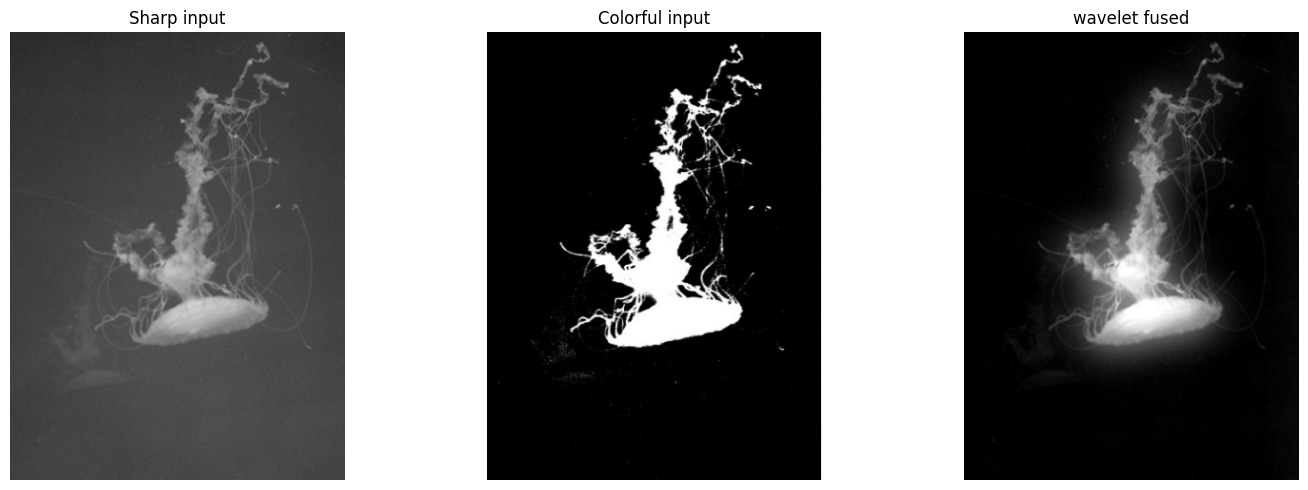

In [14]:
if __name__ == "__main__":
    sharp_img = "jelly2.png"
    colorful_img = "jelly1.png"

    pipe = Fusion(sharp_img, colorful_img)

    method = "wavelet"              # "freq", "wavelet", "luminance", "fcn_poisson", "graphcut_poisson"
    out_file = "wavelet_jelly.png"

    pipe.run_and_show(method, out_file)

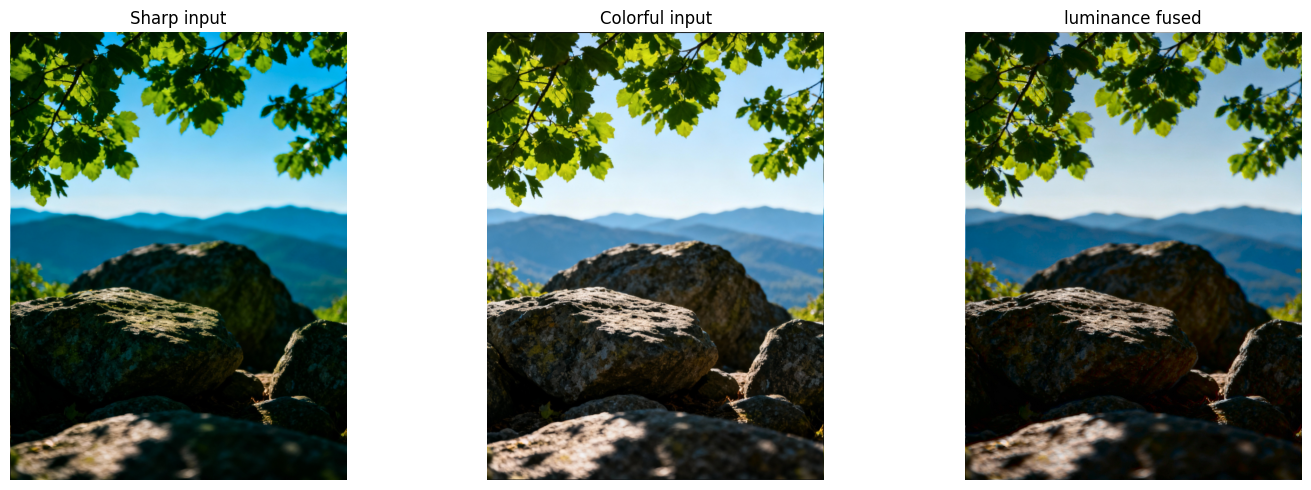

In [15]:
if __name__ == "__main__":
    sharp_img = "img2.png"
    colorful_img = "img1.png"

    pipe = Fusion(sharp_img, colorful_img)

    method = "luminance"              # "freq", "wavelet", "luminance", "fcn_poisson", "graphcut_poisson"
    out_file = "luminance_rocks.png"

    pipe.run_and_show(method, out_file)


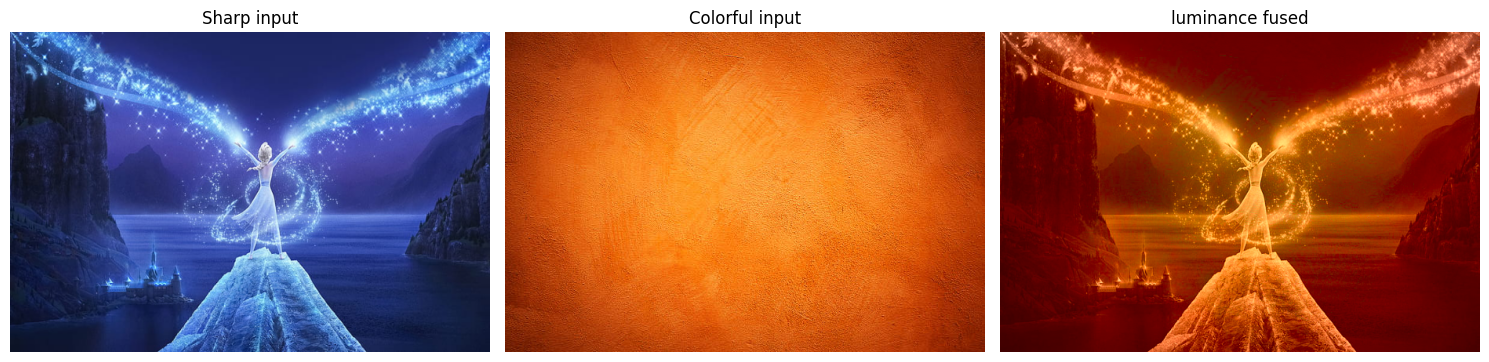

In [16]:
if __name__ == "__main__":
    sharp_img = "elsa.jpg"
    colorful_img = "orange.jpg"

    pipe = Fusion(sharp_img, colorful_img)

    method = "luminance"              # "freq", "wavelet", "luminance", "fcn_poisson", "graphcut_poisson"
    out_file = "luminance_elsa_fire.png"

    pipe.run_and_show(method, out_file)
